In [5]:
import pandas as pd

df = pd.read_excel('/data/xiaohongshu2.xlsx')
df.head()

##inputting excel file into ipynb as a Data Frame

,Username,Comment
0,京东秒送,今天老板穿我的衣服，真帅
1,假装退休日记,雷总好亲民啊
2,LUX曼友旅行生活,看吧，一旦打工谁都会变成命苦的样子
3,Jeffery,没洗头，衣服也邋邋遢遢的，差点让东哥外卖放门口
4,无有,必须要支持京东，不然美团一家独大，会越来越无法无天


In [7]:
print("Displaying the first 5 rows of the DataFrame:")
print(df.head())

print("\nDisplaying DataFrame information (column names, non-null counts, and data types):")
df.info()

print("\nDisplaying column names:")
print(df.columns)

Displaying the first 5 rows of the DataFrame:
    Username                    Comment
0       京东秒送               今天老板穿我的衣服，真帅
1     假装退休日记                     雷总好亲民啊
2  LUX曼友旅行生活          看吧，一旦打工谁都会变成命苦的样子
3    Jeffery    没洗头，衣服也邋邋遢遢的，差点让东哥外卖放门口
4         无有  必须要支持京东，不然美团一家独大，会越来越无法无天

Displaying DataFrame information (column names, non-null counts, and data types):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5980 entries, 0 to 5979
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Username  5973 non-null   object
 1   Comment   4546 non-null   object
dtypes: object(2)
memory usage: 93.6+ KB

Displaying column names:
Index(['Username', 'Comment'], dtype='object')


In [8]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return text
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = re.sub(r'[^一-龥a-zA-Z\s]', '', text) # Keep Chinese, English letters and spaces
    # Remove numbers (already handled by the above regex if only keeping specific chars)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Comment'] = df['Comment'].apply(clean_text)
print("First 5 rows of 'Comment' column after cleaning:")
print(df['Comment'].head())

First 5 rows of 'Comment' column after cleaning:
0                今天老板穿我的衣服真帅
1                     雷总好亲民啊
2           看吧一旦打工谁都会变成命苦的样子
3      没洗头衣服也邋邋遢遢的差点让东哥外卖放门口
4    必须要支持京东不然美团一家独大会越来越无法无天
Name: Comment, dtype: object


In [9]:
pip install snownlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 48.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for snownlp: filename=snownlp-0.12.3-py3-none-any.whl size=37760946 sha256=243d01f1338fec4ef9ff13e4ffb5ea26151f50600a9f359f7225728b2ddd208a
  Stored in directory: /root/.cache/pip/wheels/8a/0a/37/f15b8568f5463f1427466f701e9d3ba514035eb703f885efee
Successfully built snownlp


In [14]:
from snownlp import SnowNLP

def get_sentiment_score(text):
    if isinstance(text, str):
        if not text.strip(): # Handle empty or whitespace-only strings
            return None
        s = SnowNLP(text)
        return s.sentiments
    return None

df['sentiment_score'] = df['Comment'].apply(get_sentiment_score)
print("First 5 rows of DataFrame with sentiment scores:")
df.head()

First 5 rows of DataFrame with sentiment scores:


,Username,Comment,sentiment_score
0,京东秒送,今天老板穿我的衣服真帅,0.349914
1,假装退休日记,雷总好亲民啊,0.959282
2,LUX曼友旅行生活,看吧一旦打工谁都会变成命苦的样子,0.975636
3,Jeffery,没洗头衣服也邋邋遢遢的差点让东哥外卖放门口,0.138603
4,无有,必须要支持京东不然美团一家独大会越来越无法无天,0.920878


### Sentiment Category Pie Chart

Let's visualize the distribution of sentiment categories using a pie chart to see the proportion of positive, neutral, and negative comments.

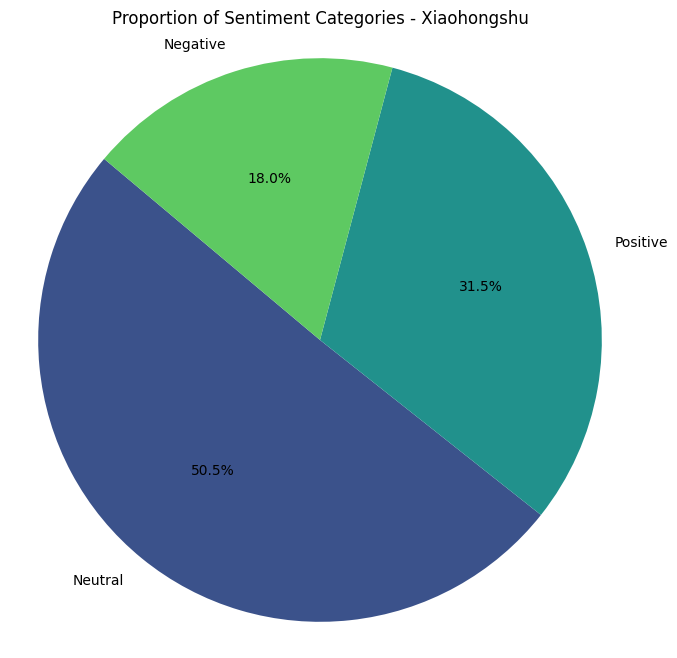

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn for color_palette

# Define sentiment categories
def categorize_sentiment(score):
    if score > 0.65: # Threshold for positive sentiment
        return 'Positive'
    elif score < 0.35: # Threshold for negative sentiment
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_category'] = df['sentiment_score'].apply(categorize_sentiment)

# Count the occurrences of each category
sentiment_counts = df['sentiment_category'].value_counts()

# Create a pie chart of sentiment categories
plt.figure(figsize=(8, 8))
plt.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(sentiment_counts)))
plt.title('Proportion of Sentiment Categories - Xiaohongshu')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Word Cloud of Comments

To understand the most frequently used words in the comments, let's generate a word cloud. Since the comments are in Chinese, we'll use `jieba` for word segmentation.

In [16]:
pip install wordcloud jieba

Chinese font 'fonts-wqy-zenhei' already installed.


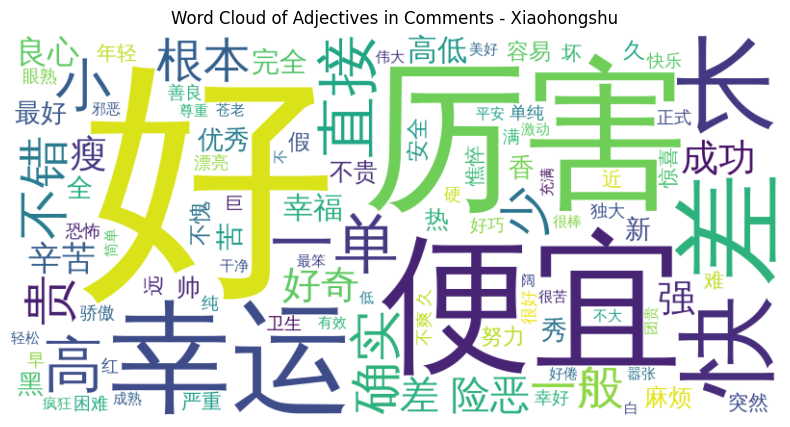

In [19]:
from wordcloud import WordCloud
import jieba.posseg as pseg
import matplotlib.pyplot as plt
import os

# Install Chinese font if not already installed or if previous font caused issues
font_path = '/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc'

if not os.path.exists(font_path):
    print("Installing Chinese font 'fonts-wqy-zenhei'...")
    try:
        !apt-get -qq install -y fonts-wqy-zenhei
        print("Chinese font installed successfully.")
    except Exception as e:
        print(f"Error installing font: {e}")
        print("Falling back to a default font (Chinese characters may not display correctly).")
        font_path = None # Indicate that a proper Chinese font couldn't be set
else:
    print("Chinese font 'fonts-wqy-zenhei' already installed.")

# Concatenate all comments into a single string
all_comments = ' '.join(df['Comment'].astype(str))

# Use jieba for Chinese word segmentation and part-of-speech tagging
words_with_pos = pseg.cut(all_comments)

# Filter for adjectives (tag 'a') and exclude specified words
excluded_words = {'老', '大'}
adjectives = [word for word, flag in words_with_pos if 'a' in flag and word not in excluded_words]
filtered_comments = ' '.join(adjectives)

# Create the word cloud object
if font_path and os.path.exists(font_path):
    wordcloud = WordCloud(width=800, height=400, background_color='white', font_path=font_path, max_words=100).generate(filtered_comments)

    # Display the generated image:
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Adjectives in Comments - Xiaohongshu')
    plt.show()
else:
    print("Word cloud cannot be generated due to missing or invalid font.")

The `font_path` for the word cloud was updated to install `fonts-wqy-zenhei` via `apt-get` and use its `.ttc` file. This approach is more reliable for ensuring Chinese characters are displayed correctly in the word cloud in the Colab environment. If the installation or font path acquisition fails, the word cloud might not be generated or might not render Chinese characters properly.

The word cloud generation has been modified to now filter for only adjectives (`'a'` tag from `jieba.posseg`) to show only descriptive words.

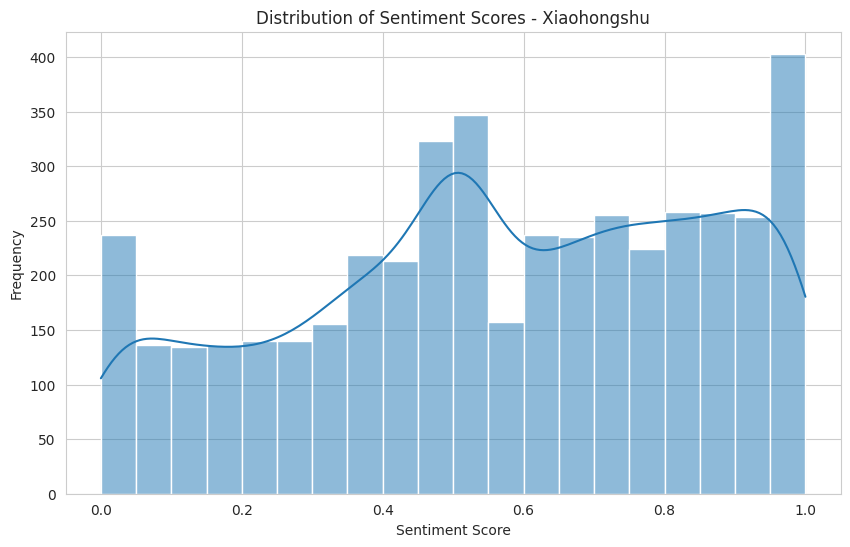

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for better aesthetics
sns.set_style("whitegrid")

# Create a histogram of sentiment scores
plt.figure(figsize=(10, 6))
sns.histplot(df['sentiment_score'], bins=20, kde=True)
plt.title('Distribution of Sentiment Scores - Xiaohongshu')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.show()

### Sentiment Category Distribution

Next, let's categorize the sentiment scores into 'Positive', 'Neutral', and 'Negative' based on common thresholds and visualize their distribution using a bar chart.

/tmp/ipykernel_1683/2641721837.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


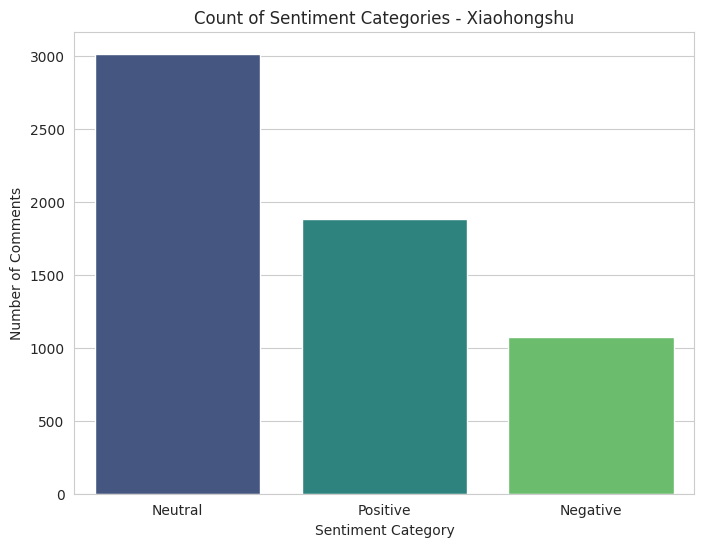

In [21]:
# Define sentiment categories
def categorize_sentiment(score):
    if score > 0.65: # Threshold for positive sentiment
        return 'Positive'
    elif score < 0.35: # Threshold for negative sentiment
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_category'] = df['sentiment_score'].apply(categorize_sentiment)

# Count the occurrences of each category
sentiment_counts = df['sentiment_category'].value_counts()

# Create a bar chart of sentiment categories
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.title('Count of Sentiment Categories - Xiaohongshu')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Comments')
plt.show()

The `sentiment_score` ranges from 0 to 1, where values closer to 1 indicate positive sentiment and values closer to 0 indicate negative sentiment. A score around 0.5 usually suggests a neutral sentiment. You can now further analyze these scores, for example, by categorizing them into positive, negative, and neutral, or by looking at their distribution.